# Understand the customer segments and extract marketing insights.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
data = pd.read_csv("../data/customer_segments.csv")

In [3]:
data.head()

,customer_unique_id,total_orders,total_spent,average_order_value,first_purchase,last_purchase,recency_days,cluster
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,2017-09-29 15:24:52,2017-09-29 15:24:52,383.087106,1
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.340,2018-07-24 20:41:01,2018-08-17 20:06:36,60.891458,2
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,2017-04-01 15:58:40,2017-04-01 15:58:41,564.063623,2
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,2018-07-15 14:49:44,2018-07-15 14:49:44,94.111505,1
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,2017-02-12 20:37:36,2017-02-12 20:37:36,611.869931,1


In [4]:
data.shape

(96095, 8)

## Check cluster distribution 
How many cutomers are in each segment?

In [5]:
cluster_counts = data['cluster'].value_counts().sort_index()
cluster_counts

cluster
0    31474
1    13187
2     2997
3    25533
4    22904
Name: count, dtype: int64

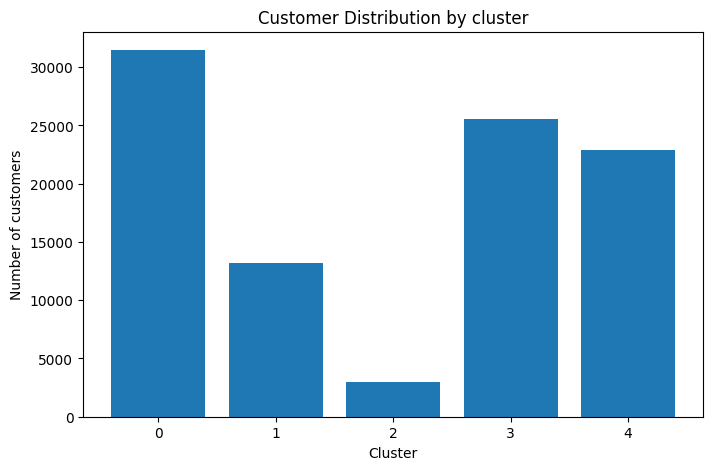

In [6]:
plt.figure(figsize=(8,5))
plt.bar(
    cluster_counts.index,
    cluster_counts.values
)
plt.xlabel("Cluster")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by cluster")
plt.show()

## Create the cluster profile table

In [7]:
cluster_profile = data.groupby("cluster")[
    [
        "total_orders",
        "total_spent",
        "average_order_value",
        "recency_days"
    ]
].mean()
cluster_profile

,total_orders,total_spent,average_order_value,recency_days
cluster,,,,
0,1.000000,149.608375,149.608375,195.194539
1,1.000000,515.316516,515.316516,317.798525
2,2.116116,314.989226,148.500545,268.672901
3,1.000000,50.674578,50.674578,218.053035
4,1.000000,98.966229,98.966229,479.702833


## Add customer count percentage

In [8]:
cluster_profile['customer_count'] = cluster_counts
cluster_profile["percentage"] = (
    cluster_profile['customer_count']
    /len(data)
    *100
)

In [9]:
cluster_profile

,total_orders,total_spent,average_order_value,recency_days,customer_count,percentage
cluster,,,,,,
0,1.000000,149.608375,149.608375,195.194539,31474,32.753005
1,1.000000,515.316516,515.316516,317.798525,13187,13.722878
2,2.116116,314.989226,148.500545,268.672901,2997,3.118789
3,1.000000,50.674578,50.674578,218.053035,25533,26.570581
4,1.000000,98.966229,98.966229,479.702833,22904,23.834747


## Visualize the clusters profile
Average total spent by Cluster

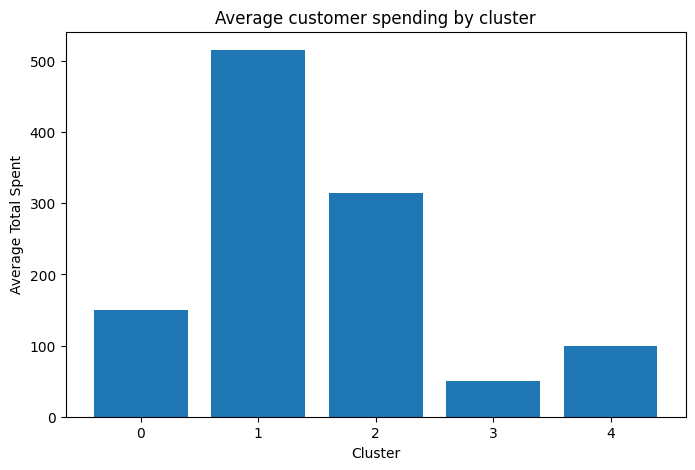

In [10]:
plt.figure(figsize=(8,5))
plt.bar(
    cluster_profile.index,
    cluster_profile['total_spent']
)
plt.xlabel("Cluster")
plt.ylabel("Average Total Spent")
plt.title("Average customer spending by cluster")
plt.show()

## Average Order Value by Cluster

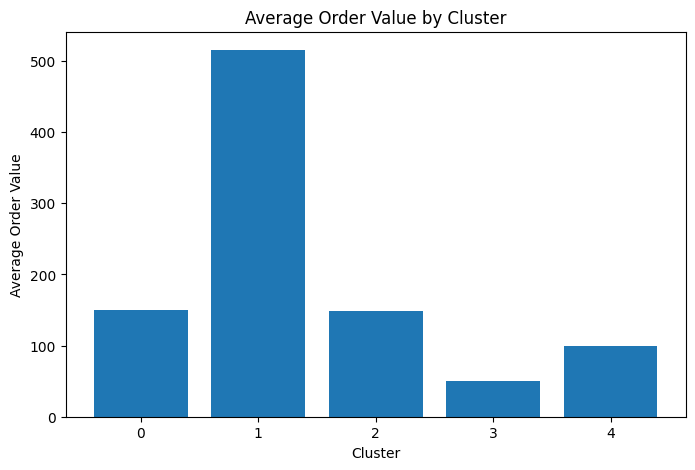

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_profile.index,
    cluster_profile["average_order_value"]
)

plt.xlabel("Cluster")
plt.ylabel("Average Order Value")
plt.title("Average Order Value by Cluster")

plt.show()

## Average Number of Orders by Clusters

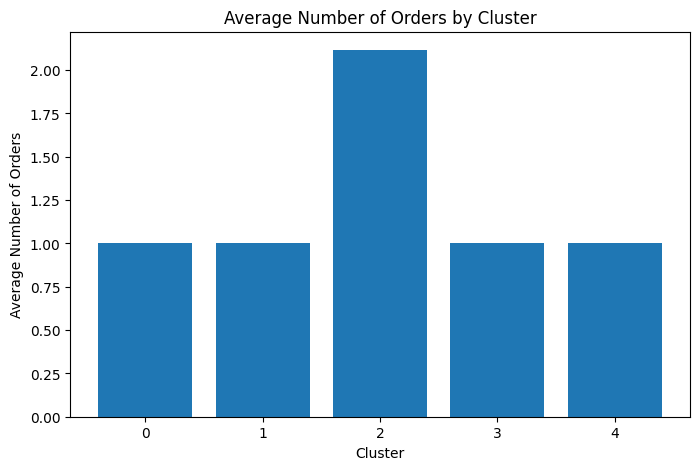

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_profile.index,
    cluster_profile["total_orders"]
)

plt.xlabel("Cluster")
plt.ylabel("Average Number of Orders")
plt.title("Average Number of Orders by Cluster")

plt.show()

## Average Customer Recency by Cluster

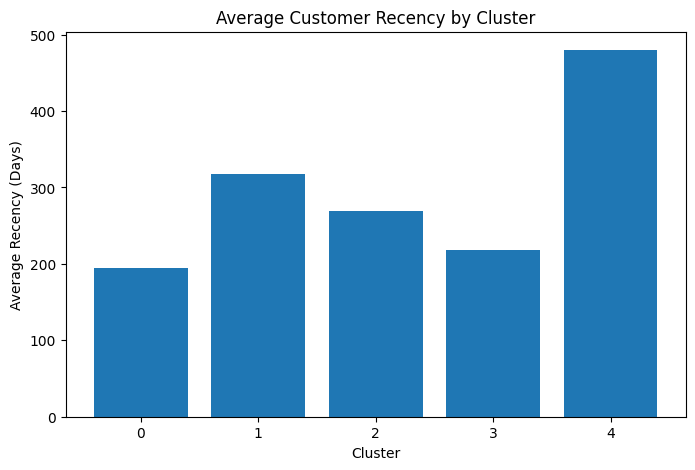

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_profile.index,
    cluster_profile["recency_days"]
)

plt.xlabel("Cluster")
plt.ylabel("Average Recency (Days)")
plt.title("Average Customer Recency by Cluster")

plt.show()

## Visulize clusters across two features together
Recency vs Total Spending

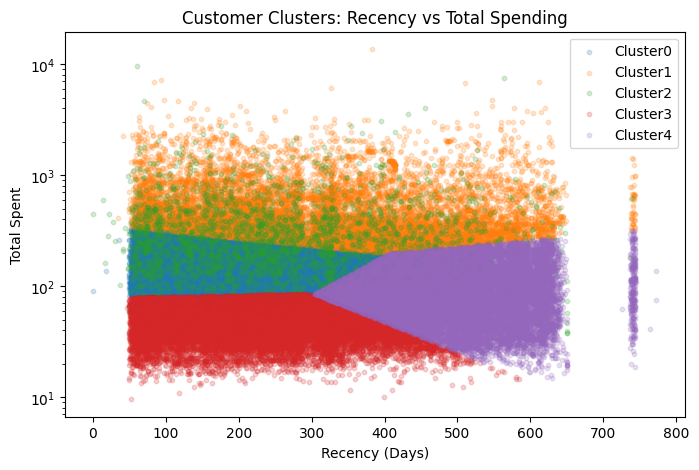

In [14]:
plt.figure(figsize=(8, 5))
for cluster in sorted(data['cluster'].unique()):
    cluster_data = data[data['cluster'] == cluster]
    plt.scatter(
        cluster_data['recency_days'],
        cluster_data['total_spent'],
        label =f"Cluster{cluster}",
        alpha=0.2,
        s =10
        
    )
plt.yscale("log")
plt.xlabel("Recency (Days)")
plt.ylabel("Total Spent")
plt.title("Customer Clusters: Recency vs Total Spending")
plt.legend()

plt.show()

## We will compare each cluster against the overall customer population 

In [15]:
features = [
    "total_orders",
    "total_spent",
    "average_order_value",
    "recency_days"
]

In [16]:
overall_average = data[features].mean()
overall_average

total_orders             1.034809
total_spent            166.594226
average_order_value    161.401796
recency_days           288.196437
dtype: float64

In [17]:
cluster_comparison = cluster_profile.copy()

In [18]:
cluster_comparison = cluster_profile.copy()

for feature in features:
    cluster_comparison[f"{feature}_vs_average"] = (
        cluster_comparison[feature]
        / overall_average[feature]
    )
cluster_comparison

,total_orders,total_spent,average_order_value,recency_days,customer_count,percentage,total_orders_vs_average,total_spent_vs_average,average_order_value_vs_average,recency_days_vs_average
cluster,,,,,,,,,,
0,1.000000,149.608375,149.608375,195.194539,31474,32.753005,0.966362,0.898041,0.926931,0.677297
1,1.000000,515.316516,515.316516,317.798525,13187,13.722878,0.966362,3.093244,3.192756,1.102715
2,2.116116,314.989226,148.500545,268.672901,2997,3.118789,2.044933,1.890757,0.920067,0.932256
3,1.000000,50.674578,50.674578,218.053035,25533,26.570581,0.966362,0.304180,0.313965,0.756613
4,1.000000,98.966229,98.966229,479.702833,22904,23.834747,0.966362,0.594056,0.613167,1.664500


## Replacing group numbers with suggested names that describe each group based on the observed results.

In [19]:
segments_name = {
    0: "Recent Mid-Value Customers",
    1: "High-Value Lapsed Customers",
    2: "Loyal Repeat Customers",
    3: "Recent Low_Value Customers",
    4: "Inactive Low_Value Customers"
}


In [20]:
data["segment_name"] = data["cluster"].map(segments_name)

In [21]:
data.head()

,customer_unique_id,total_orders,total_spent,average_order_value,first_purchase,last_purchase,recency_days,cluster,segment_name
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,2017-09-29 15:24:52,2017-09-29 15:24:52,383.087106,1,High-Value Lapsed Customers
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.340,2018-07-24 20:41:01,2018-08-17 20:06:36,60.891458,2,Loyal Repeat Customers
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,2017-04-01 15:58:40,2017-04-01 15:58:41,564.063623,2,Loyal Repeat Customers
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,2018-07-15 14:49:44,2018-07-15 14:49:44,94.111505,1,High-Value Lapsed Customers
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,2017-02-12 20:37:36,2017-02-12 20:37:36,611.869931,1,High-Value Lapsed Customers


In [22]:
data[
    [
        "customer_unique_id",
        "cluster",
        "segment_name"
    ]
].head()

,customer_unique_id,cluster,segment_name
0,0a0a92112bd4c708ca5fde585afaa872,1,High-Value Lapsed Customers
1,46450c74a0d8c5ca9395da1daac6c120,2,Loyal Repeat Customers
2,da122df9eeddfedc1dc1f5349a1a690c,2,Loyal Repeat Customers
3,763c8b1c9c68a0229c42c9fc6f662b93,1,High-Value Lapsed Customers
4,dc4802a71eae9be1dd28f5d788ceb526,1,High-Value Lapsed Customers


## Final segment summary

In [23]:
final_summary = data.groupby("segment_name").agg(
    customer_count=("customer_unique_id", "count"),
    avg_orders=("total_orders", "mean"),
    avg_total_spent=("total_spent", "mean"),
    avg_order_value=("average_order_value", "mean"),
    avg_recency_days=("recency_days", "mean")
)

final_summary

,customer_count,avg_orders,avg_total_spent,avg_order_value,avg_recency_days
segment_name,,,,,
High-Value Lapsed Customers,13187,1.000000,515.316516,515.316516,317.798525
Inactive Low_Value Customers,22904,1.000000,98.966229,98.966229,479.702833
Loyal Repeat Customers,2997,2.116116,314.989226,148.500545,268.672901
Recent Low_Value Customers,25533,1.000000,50.674578,50.674578,218.053035
Recent Mid-Value Customers,31474,1.000000,149.608375,149.608375,195.194539


In [24]:
final_summary["customer_percentage"] = (
    final_summary['customer_count'] / len(data) *100
)

In [25]:
final_summary.round(2)

,customer_count,avg_orders,avg_total_spent,avg_order_value,avg_recency_days,customer_percentage
segment_name,,,,,,
High-Value Lapsed Customers,13187,1.00,515.32,515.32,317.80,13.72
Inactive Low_Value Customers,22904,1.00,98.97,98.97,479.70,23.83
Loyal Repeat Customers,2997,2.12,314.99,148.50,268.67,3.12
Recent Low_Value Customers,25533,1.00,50.67,50.67,218.05,26.57
Recent Mid-Value Customers,31474,1.00,149.61,149.61,195.19,32.75


## Customer distribution by segment and Insights

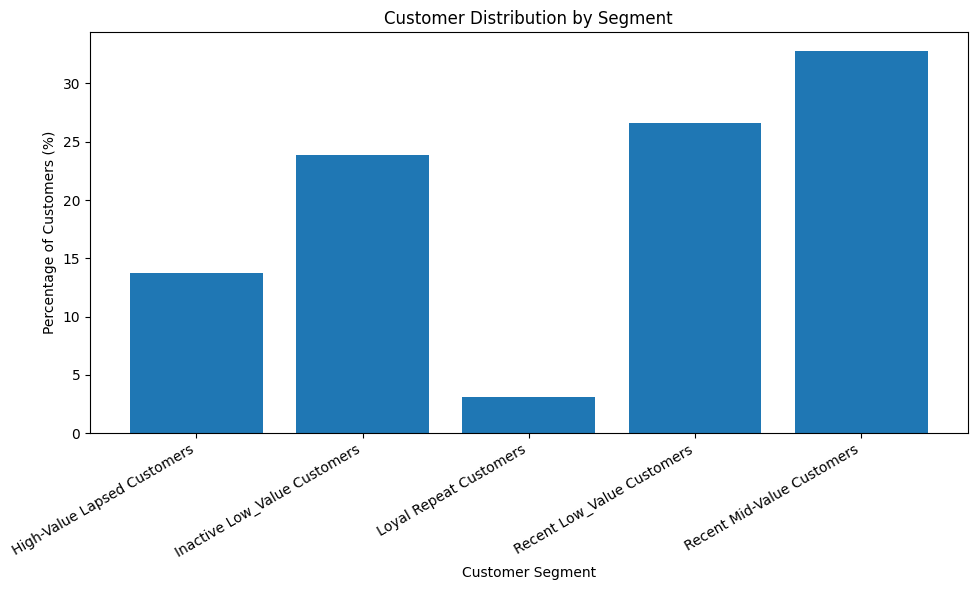

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_summary.index,
    final_summary["customer_percentage"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Percentage of Customers (%)")
plt.title("Customer Distribution by Segment")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

### Insight

- Recent Mid-Value Customers are the largest segment, representing 32.75% of customers.
- Recent Low-Value Customers represent 26.57%.
- Inactive Low-Value Customers account for 23.83%.
- High-Value Lapsed Customers represent 13.72%.
- Loyal Repeat Customers represent only 3.12% of the customer base.

The relatively small proportion of repeat customers suggests an opportunity
to investigate strategies for increasing repeat purchases and customer retention.

## Value vs Recency
bubble chart:

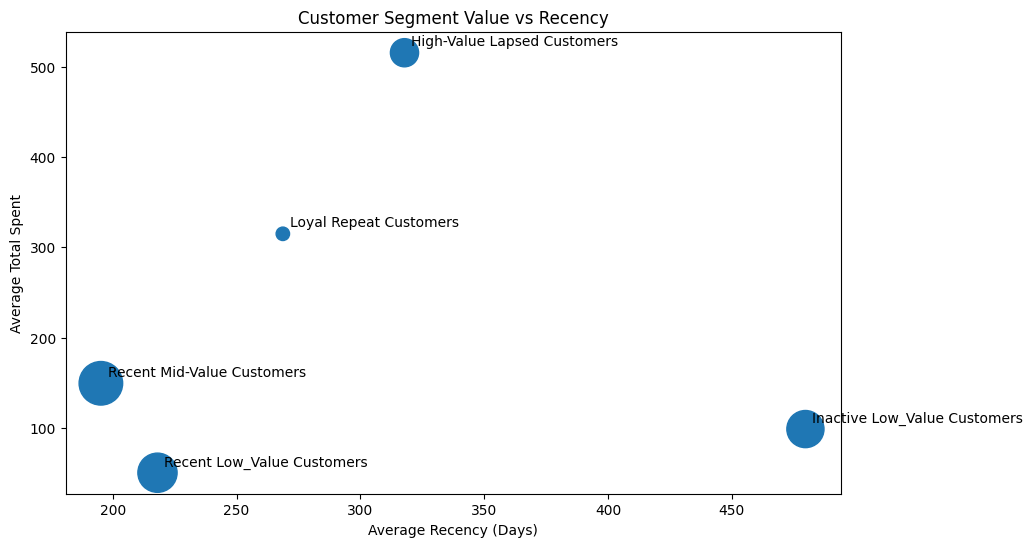

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(
    final_summary["avg_recency_days"],
    final_summary["avg_total_spent"],
    s=final_summary["customer_percentage"] * 30
)

for segment in final_summary.index:
    plt.annotate(
        segment,
        (
            final_summary.loc[segment, "avg_recency_days"],
            final_summary.loc[segment, "avg_total_spent"]
        ),
        xytext=(5,5),
        textcoords="offset points"

    )

plt.xlabel("Average Recency (Days)")
plt.ylabel("Average Total Spent")
plt.title("Customer Segment Value vs Recency")

plt.show()

### Insight: Customer Value vs Recency

The segment comparison reveals clear differences in customer value and activity.

- High-Value Lapsed Customers have the highest average spending but relatively high recency, making them a potential target for re-engagement campaigns.
- Loyal Repeat Customers demonstrate strong customer value and are distinguished by repeat purchasing behavior, despite representing only a small proportion of the customer base.
- Recent Mid-Value Customers form the largest segment and combine relatively recent activity with moderate spending, creating an opportunity to encourage repeat purchases.
- Recent Low-Value Customers are active relatively recently but generate low monetary value.
- Inactive Low-Value Customers have the highest recency and relatively low spending, indicating the weakest combination of recent activity and customer value.

Bubble size represents the percentage of customers in each segment.

## Marketing Strategy and Recommendations

In [28]:
marketing_strategy = pd.DataFrame({
    "segment_name": [
        "High-Value Lapsed Customers",
        "Loyal Repeat Customers",
        "Recent Mid-Value Customers",
        "Recent Low-Value Customers",
        "Inactive Low-Value Customers"
    ],

    "objective": [
        "Reactivate high-value customers and encourage a second purchase",
        "Retain loyal customers and increase purchase frequency",
        "Convert recent customers into repeat and higher-value customers",
        "Increase customer value and encourage a second purchase",
        "Reactivate inactive customers using cost-efficient campaigns"
    ],

    "strategy": [
        "Run personalized re-engagement campaigns, provide exclusive benefits, recommend relevant premium products, and collect customer feedback",

        "Build a loyalty program, provide rewards for future purchases, collect feedback about repeat-purchase drivers, and provide personalized recommendations",

        "Collect post-purchase feedback, test second-purchase incentives such as free delivery, and recommend relevant higher-value products",

        "Use personalized cross-selling and product bundles to encourage customers to purchase multiple relevant products",

        "Run low-cost win-back campaigns with limited-time offers, personalized recommendations, and incentives toward future purchases"
    ],

    "primary_kpi": [
        "Reactivation Rate",
        "Repeat Purchase Rate",
        "Second Purchase Rate",
        "Average Order Value",
        "Reactivation Rate"
    ]
})

marketing_strategy

,segment_name,objective,strategy,primary_kpi
0,High-Value Lapsed Customers,Reactivate high-value customers and encourage ...,"Run personalized re-engagement campaigns, prov...",Reactivation Rate
1,Loyal Repeat Customers,Retain loyal customers and increase purchase f...,"Build a loyalty program, provide rewards for f...",Repeat Purchase Rate
2,Recent Mid-Value Customers,Convert recent customers into repeat and highe...,"Collect post-purchase feedback, test second-pu...",Second Purchase Rate
3,Recent Low-Value Customers,Increase customer value and encourage a second...,Use personalized cross-selling and product bun...,Average Order Value
4,Inactive Low-Value Customers,Reactivate inactive customers using cost-effic...,Run low-cost win-back campaigns with limited-t...,Reactivation Rate


In [29]:
marketing_strategy["secondary_kpis"] = [
    "Second Purchase Rate, Campaign ROI, AOV",
    "Purchase Frequency, Retention Rate, CLV",
    "AOV, Conversion Rate, Campaign ROI",
    "Items per Order, Second Purchase Rate, Conversion Rate",
    "Conversion Rate, Repeat Purchase Rate, Campaign ROI"
]

In [30]:
marketing_strategy

,segment_name,objective,strategy,primary_kpi,secondary_kpis
0,High-Value Lapsed Customers,Reactivate high-value customers and encourage ...,"Run personalized re-engagement campaigns, prov...",Reactivation Rate,"Second Purchase Rate, Campaign ROI, AOV"
1,Loyal Repeat Customers,Retain loyal customers and increase purchase f...,"Build a loyalty program, provide rewards for f...",Repeat Purchase Rate,"Purchase Frequency, Retention Rate, CLV"
2,Recent Mid-Value Customers,Convert recent customers into repeat and highe...,"Collect post-purchase feedback, test second-pu...",Second Purchase Rate,"AOV, Conversion Rate, Campaign ROI"
3,Recent Low-Value Customers,Increase customer value and encourage a second...,Use personalized cross-selling and product bun...,Average Order Value,"Items per Order, Second Purchase Rate, Convers..."
4,Inactive Low-Value Customers,Reactivate inactive customers using cost-effic...,Run low-cost win-back campaigns with limited-t...,Reactivation Rate,"Conversion Rate, Repeat Purchase Rate, Campaig..."


In [31]:
marketing_strategy.index = range(1, len(marketing_strategy)+1)

In [32]:
marketing_strategy

,segment_name,objective,strategy,primary_kpi,secondary_kpis
1,High-Value Lapsed Customers,Reactivate high-value customers and encourage ...,"Run personalized re-engagement campaigns, prov...",Reactivation Rate,"Second Purchase Rate, Campaign ROI, AOV"
2,Loyal Repeat Customers,Retain loyal customers and increase purchase f...,"Build a loyalty program, provide rewards for f...",Repeat Purchase Rate,"Purchase Frequency, Retention Rate, CLV"
3,Recent Mid-Value Customers,Convert recent customers into repeat and highe...,"Collect post-purchase feedback, test second-pu...",Second Purchase Rate,"AOV, Conversion Rate, Campaign ROI"
4,Recent Low-Value Customers,Increase customer value and encourage a second...,Use personalized cross-selling and product bun...,Average Order Value,"Items per Order, Second Purchase Rate, Convers..."
5,Inactive Low-Value Customers,Reactivate inactive customers using cost-effic...,Run low-cost win-back campaigns with limited-t...,Reactivation Rate,"Conversion Rate, Repeat Purchase Rate, Campaig..."


# exporting the results

In [33]:
data.head()

,customer_unique_id,total_orders,total_spent,average_order_value,first_purchase,last_purchase,recency_days,cluster,segment_name
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,2017-09-29 15:24:52,2017-09-29 15:24:52,383.087106,1,High-Value Lapsed Customers
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.340,2018-07-24 20:41:01,2018-08-17 20:06:36,60.891458,2,Loyal Repeat Customers
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,2017-04-01 15:58:40,2017-04-01 15:58:41,564.063623,2,Loyal Repeat Customers
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,2018-07-15 14:49:44,2018-07-15 14:49:44,94.111505,1,High-Value Lapsed Customers
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,2017-02-12 20:37:36,2017-02-12 20:37:36,611.869931,1,High-Value Lapsed Customers


In [34]:
data.to_csv(
    "../data/final_customer_segments.csv",
    index=False
)

In [35]:
final_summary.head()

,customer_count,avg_orders,avg_total_spent,avg_order_value,avg_recency_days,customer_percentage
segment_name,,,,,,
High-Value Lapsed Customers,13187,1.000000,515.316516,515.316516,317.798525,13.722878
Inactive Low_Value Customers,22904,1.000000,98.966229,98.966229,479.702833,23.834747
Loyal Repeat Customers,2997,2.116116,314.989226,148.500545,268.672901,3.118789
Recent Low_Value Customers,25533,1.000000,50.674578,50.674578,218.053035,26.570581
Recent Mid-Value Customers,31474,1.000000,149.608375,149.608375,195.194539,32.753005


In [36]:
final_summary.to_csv(
    "../data/segment_summary.csv"
)

In [37]:
marketing_strategy.to_csv(
    "../data/marketing_strategy.csv",
    index_label="strategy_id"
)

In [38]:
import os

print(os.path.exists("../data/final_customer_segments.csv"))
print(os.path.exists("../data/segment_summary.csv"))
print(os.path.exists("../data/marketing_strategy.csv"))

True
True
True
